# 27-40 Neighborhood-price  columns by monday the 22nd - KEEP TRACK OF EVERYTHING

### Enviorment Setup

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
# https://drive.google.com/file/d/1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8/view?usp=sharing

# Download data to Google Colab Environment
!gdown 1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8

Downloading...
From: https://drive.google.com/uc?id=1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8
To: /content/listings.csv
100% 22.7M/22.7M [00:00<00:00, 235MB/s]


In [87]:
df = pd.read_csv('listings.csv')

In [88]:
df.shape

(10669, 79)

In [89]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
description,200
neighborhood_overview,6075
host_name,2
host_since,2
host_location,3591
host_about,6737
host_response_time,2300
host_response_rate,2300
host_acceptance_rate,1396
host_is_superhost,440


### Fix missing values / outliers

In [90]:
# Select only columns 27–40
cols = ['neighbourhood','neighbourhood_cleansed','neighbourhood_group_cleansed','latitude','longitude','property_type','room_type','accommodates','bathrooms','bathrooms_text','bedrooms','beds','amenities','price']
df = df[cols]
print(df.shape)

(10669, 14)


In [91]:
print("\nRaw price values (before cleaning):")
print(df['price'].head(10))


Raw price values (before cleaning):
0     $53.00
1     $49.00
2     $56.00
3     $42.00
4     $43.00
5     $58.00
6        NaN
7    $247.00
8    $103.00
9     $85.00
Name: price, dtype: object


In [92]:
# Force text, remove symbols, convert to numeric
df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows with missing or zero price
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]
print("\nCleaned price values:")
print(df['price'].head(10))
print("Price dtype:", df['price'].dtype)
print("Shape after price cleaning:", df.shape)


Cleaned price values:
0      53.0
1      49.0
2      56.0
3      42.0
4      43.0
5      58.0
7     247.0
8     103.0
9      85.0
10    100.0
Name: price, dtype: float64
Price dtype: float64
Shape after price cleaning: (9482, 14)


In [93]:
cols_to_fill = ['bathrooms', 'bedrooms', 'beds']
for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [94]:
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5*IQR, Q3 + 1.5*IQR

df['price'] = df['price'].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped using IQR bounds.")
print("Final shape:", df.shape)

Outliers capped using IQR bounds.
Final shape: (9482, 14)


### Drop rows or columns that will not be used

In [95]:
df = df.drop(columns=['neighbourhood','neighbourhood_group_cleansed','bathrooms_text'])
print("Shape after dropping irrelevant columns:", df.shape)

Shape after dropping irrelevant columns: (9482, 11)


### IF NEEDED: add new columns with recoded values, binning, transformations, standardizing, PCA’s, etc.

In [ ]:
# For columns 27–40, additional feature engineering was not necessary.
# All variables were already interpretable, clean, and suitable for modeling.
# Therefore, no recoding, binning, transformations, or dimensionality reduction was done.

### Ready to model, no missing values, no outliers, export to a .csv and submit with the paper

In [96]:
# Handle remaining missing values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Export the cleaned data to a CSV file
df.to_csv('cleaned_listings.csv', index=False)

print("Cleaned data exported to 'cleaned_listings.csv'")

Cleaned data exported to 'cleaned_listings.csv'


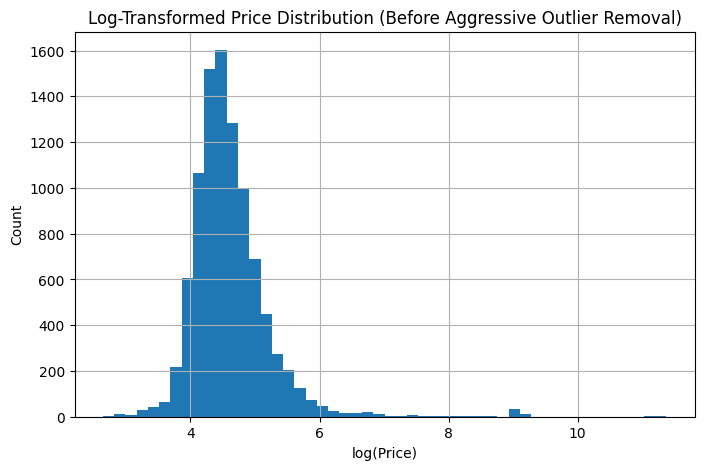

In [97]:
# Reload the original data to visualize the price distribution before outlier removal
df_original = pd.read_csv('listings.csv')

# Clean the price column for the original data for visualization
df_original['price'] = df_original['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df_original['price'] = pd.to_numeric(df_original['price'], errors='coerce')
df_original = df_original.dropna(subset=['price'])


import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
# Use the original data for log transformation and plotting
np.log1p(df_original['price']).hist(bins=50)  # log(1+price)
plt.title("Log-Transformed Price Distribution (Before Aggressive Outlier Removal)")
plt.xlabel("log(Price)")
plt.ylabel("Count")
plt.show()

<Figure size 1000x600 with 0 Axes>

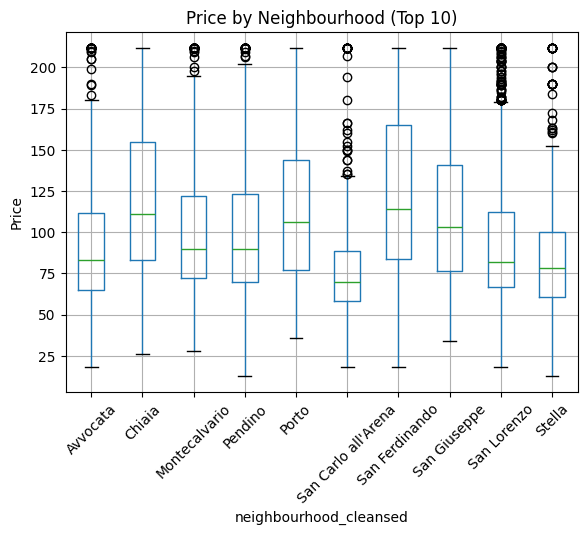

In [98]:
# Ensure df is not empty before proceeding
if not df.empty:
    top_neigh = df['neighbourhood_cleansed'].value_counts().head(10).index
    df_top = df[df['neighbourhood_cleansed'].isin(top_neigh)].copy() # Use .copy() to avoid SettingWithCopyWarning

    plt.figure(figsize=(10,6))
    df_top.boxplot(column='price', by='neighbourhood_cleansed', rot=45)
    plt.title("Price by Neighbourhood (Top 10)")
    plt.suptitle("")  # removes duplicate title
    plt.ylabel("Price")
    plt.show()
else:
    print("DataFrame is empty. Cannot generate box plot.")